In [48]:
import pandas as pd
import numpy as np
import re
import ast

hotels = pd.read_csv(r"C:\Users\aleks\Downloads\hotels.csv")
hotels.head()

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,9/22/2015,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,Friendly staff quiet comfortable room spotles...,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,48.888697,2.394540
4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,3/5/2016,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,The staff was very friendly and helpful Break...,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,52.385601,4.847060


# Работа с данными 

In [49]:
df_ml = hotels.copy()

In [50]:
# review_date - признаки
if 'review_date' in df_ml.columns:
    df_ml['review_date'] = pd.to_datetime(df_ml['review_date'], errors='coerce')
    df_ml['review_year'] = df_ml['review_date'].dt.year
    df_ml['review_month'] = df_ml['review_date'].dt.month
    df_ml['review_day'] = df_ml['review_date'].dt.day
    df_ml['review_dayofweek'] = df_ml['review_date'].dt.dayofweek
    df_ml['review_quarter'] = df_ml['review_date'].dt.quarter

# days_since_review - число
if 'days_since_review' in df_ml.columns:
    df_ml['days_since_review'] = (
        df_ml['days_since_review']
        .astype(str)
        .str.extract(r'(\d+)')[0]
        .astype(float)
    )

# Признаки из negative_review
if 'negative_review' in df_ml.columns:
    df_ml['negative_review'] = df_ml['negative_review'].fillna('')
    df_ml['neg_len'] = df_ml['negative_review'].str.len()
    df_ml['neg_words'] = df_ml['negative_review'].str.split().str.len()
    df_ml['neg_no_text'] = df_ml['negative_review'].str.contains('No Negative', case=False, na=False).astype(int)

# Признаки из positive_review
if 'positive_review' in df_ml.columns:
    df_ml['positive_review'] = df_ml['positive_review'].fillna('')
    df_ml['pos_len'] = df_ml['positive_review'].str.len()
    df_ml['pos_words'] = df_ml['positive_review'].str.split().str.len()
    df_ml['pos_no_text'] = df_ml['positive_review'].str.contains('No Positive', case=False, na=False).astype(int)

# Признаки из tags
def parse_tags(x):
    try:
        lst = ast.literal_eval(x)
        if isinstance(lst, list):
            return [str(i).strip() for i in lst]
    except:
        pass
    return []

if 'tags' in df_ml.columns:
    df_ml['tags'] = df_ml['tags'].astype(str)
    df_ml['tags_list'] = df_ml['tags'].apply(parse_tags)
    df_ml['tags_count'] = df_ml['tags_list'].apply(len)
    df_ml['is_business'] = df_ml['tags'].str.contains('Business trip', case=False, na=False).astype(int)
    df_ml['is_leisure'] = df_ml['tags'].str.contains('Leisure trip', case=False, na=False).astype(int)
    df_ml['is_couple'] = df_ml['tags'].str.contains('Couple', case=False, na=False).astype(int)
    df_ml['is_solo'] = df_ml['tags'].str.contains('Solo traveler', case=False, na=False).astype(int)
    df_ml['is_family'] = df_ml['tags'].str.contains('Family', case=False, na=False).astype(int)
    df_ml['is_mobile'] = df_ml['tags'].str.contains('mobile device', case=False, na=False).astype(int)

# Признаки из hotel_address
if 'hotel_address' in df_ml.columns:
    df_ml['hotel_address'] = df_ml['hotel_address'].fillna('')
    df_ml['address_len'] = df_ml['hotel_address'].str.len()
    df_ml['address_has_digits'] = df_ml['hotel_address'].str.contains(r'\d', na=False).astype(int)

    df_ml['country_from_address'] = df_ml['hotel_address'].str.split().str[-1]

# Координаты
if 'latlng' in df_ml.columns:
    if df_ml['latlng'].dtype == object:
        tmp = df_ml['latlng'].astype(str).str.extract(r'(-?\d+\.\d+)\s*,\s*(-?\d+\.\d+)')
        df_ml['lat'] = pd.to_numeric(tmp[0], errors='coerce')
        df_ml['lng'] = pd.to_numeric(tmp[1], errors='coerce')

# Дополнительные числовые признаки
if 'average_score' in df_ml.columns and 'reviewer_score' in df_ml.columns:
    df_ml['score_diff'] = df_ml['reviewer_score'] - df_ml['average_score']

if 'review_total_negative_word_count' in df_ml.columns and 'review_total_positive_word_count' in df_ml.columns:
    df_ml['total_review_words'] = (
        df_ml['review_total_negative_word_count'].fillna(0) +
        df_ml['review_total_positive_word_count'].fillna(0)
    )

if 'total_number_of_reviews' in df_ml.columns and 'total_number_of_reviews_reviewer_has_given' in df_ml.columns:
    df_ml['review_activity_ratio'] = (
        df_ml['total_number_of_reviews_reviewer_has_given'].fillna(0) /
        df_ml['total_number_of_reviews'].replace(0, np.nan)
    )

# Заполнение пропусков
num_cols = df_ml.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df_ml[col] = df_ml[col].fillna(df_ml[col].median())

# Удаление ненужных столбцов
drop_cols = [
    'review_date', 'negative_review', 'positive_review',
    'tags', 'tags_list', 'hotel_address',
    'hotel_name', 'reviewer_nationality',
    'country_from_address', 'latlng'
]
df_ml = df_ml.drop(columns=drop_cols, errors='ignore')

# Проверка результата
print(df_ml.info())
print(df_ml.isna().sum().sort_values(ascending=False).head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 32 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                386803 non-null  int64  
 1   average_score                               386803 non-null  float64
 2   review_total_negative_word_counts           386803 non-null  int64  
 3   total_number_of_reviews                     386803 non-null  int64  
 4   review_total_positive_word_counts           386803 non-null  int64  
 5   total_number_of_reviews_reviewer_has_given  386803 non-null  int64  
 6   reviewer_score                              386803 non-null  float64
 7   days_since_review                           386803 non-null  float64
 8   lat                                         386803 non-null  float64
 9   lng                                         386803 non-null  float64
 

In [51]:
import numpy as np
import pandas as pd

corr = df_ml.drop(columns=['reviewer_score']).corr(numeric_only=True).abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print('Количество признаков к удалению:', len(to_drop))
print(to_drop)

Количество признаков к удалению: 5
['review_quarter', 'neg_len', 'neg_words', 'pos_len', 'pos_words']


In [52]:
df_ml_reduced = df_ml.drop(columns=to_drop, errors='ignore')
print(df_ml_reduced.shape)

(386803, 27)


In [53]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import f_regression, chi2
from sklearn.preprocessing import MinMaxScaler

df_feat = df_ml.copy()

y = df_feat['reviewer_score']
X = df_feat.drop(columns=['reviewer_score'])

# Числовые признаки - ANOVA
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X_num = X[num_cols].copy().fillna(X[num_cols].median())

f_vals, p_vals = f_regression(X_num, y)

anova_df = pd.DataFrame({
    'feature': num_cols,
    'f_value': f_vals,
    'p_value': p_vals
}).sort_values('p_value')

print('ANOVA:')
print(anova_df.head(20))

# Категориальные признаки - chi2
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

if len(cat_cols) > 0:
    X_cat = X[cat_cols].copy().fillna('missing')
    X_cat = pd.get_dummies(X_cat, drop_first=False)

    # неотрицательные значения
    X_cat = MinMaxScaler().fit_transform(X_cat)

    chi_vals, chi_p_vals = chi2(X_cat, y)

    chi_df = pd.DataFrame({
        'feature': pd.get_dummies(X[cat_cols].fillna('missing'), drop_first=False).columns,
        'chi2': chi_vals,
        'p_value': chi_p_vals
    }).sort_values('p_value')

    print('\nCHI-SQUARE:')
    print(chi_df.head(20))
else:
    print('\nКатегориальных признаков нет.')

ANOVA:
                              feature       f_value        p_value
1                       average_score  5.904514e+04   0.000000e+00
2   review_total_negative_word_counts  6.665902e+04   0.000000e+00
3             total_number_of_reviews  2.094564e+03   0.000000e+00
4   review_total_positive_word_counts  1.972863e+04   0.000000e+00
15                          neg_words  6.270156e+04   0.000000e+00
14                            neg_len  6.522007e+04   0.000000e+00
17                            pos_len  2.106977e+04   0.000000e+00
29                         score_diff  3.065844e+06   0.000000e+00
24                            is_solo  2.698127e+03   0.000000e+00
23                          is_couple  1.905385e+03   0.000000e+00
22                         is_leisure  5.460550e+03   0.000000e+00
21                        is_business  5.041392e+03   0.000000e+00
19                        pos_no_text  2.621856e+04   0.000000e+00
18                          pos_words  1.791379e+04   0

In [54]:
corr = df_ml.drop(columns=['reviewer_score']).corr(numeric_only=True).abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

print('Удаляемые признаки:')
print(to_drop)

df_ml_final = df_ml.drop(columns=to_drop, errors='ignore')
print(df_ml_final.shape)

Удаляемые признаки:
['review_quarter', 'neg_len', 'neg_words', 'pos_len', 'pos_words']
(386803, 27)


In [55]:
df_ml_final.head()

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,days_since_review,lat,lng,...,is_business,is_leisure,is_couple,is_solo,is_family,is_mobile,address_len,address_has_digits,score_diff,review_activity_ratio
0,581,8.4,3,1994,4,7,10.0,531.0,51.507894,-0.143671,...,0,1,1,0,0,1,73,1,1.6,0.003511
1,299,8.3,3,1361,2,14,6.3,203.0,51.521009,-0.123097,...,1,0,1,0,0,0,61,1,-2.0,0.010287
2,32,8.9,6,406,0,14,7.5,289.0,48.845377,2.325643,...,0,1,0,1,0,1,48,1,-1.4,0.034483
3,34,7.5,0,607,11,8,10.0,681.0,48.888697,2.394540,...,0,1,0,1,0,0,50,1,2.5,0.013180
4,914,8.5,4,7586,20,10,9.6,516.0,52.385601,4.847060,...,1,0,1,0,0,0,41,1,1.1,0.001318


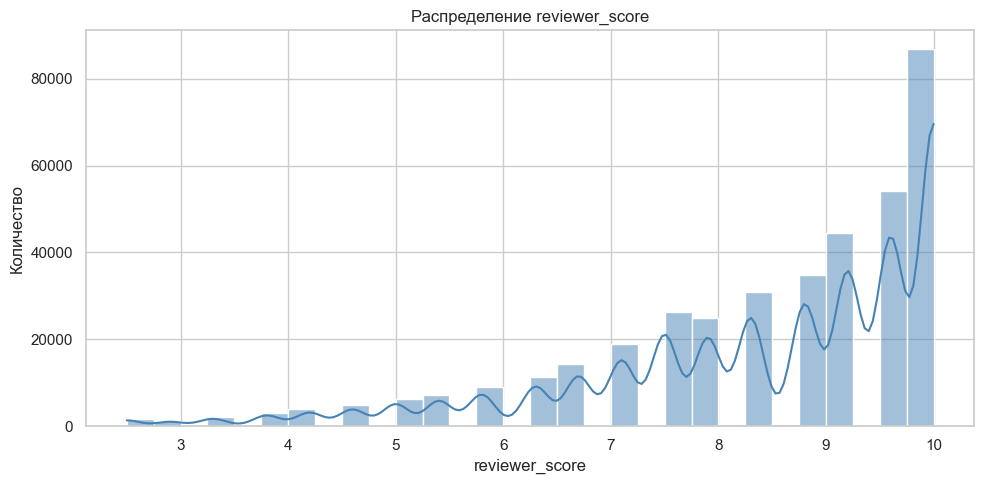

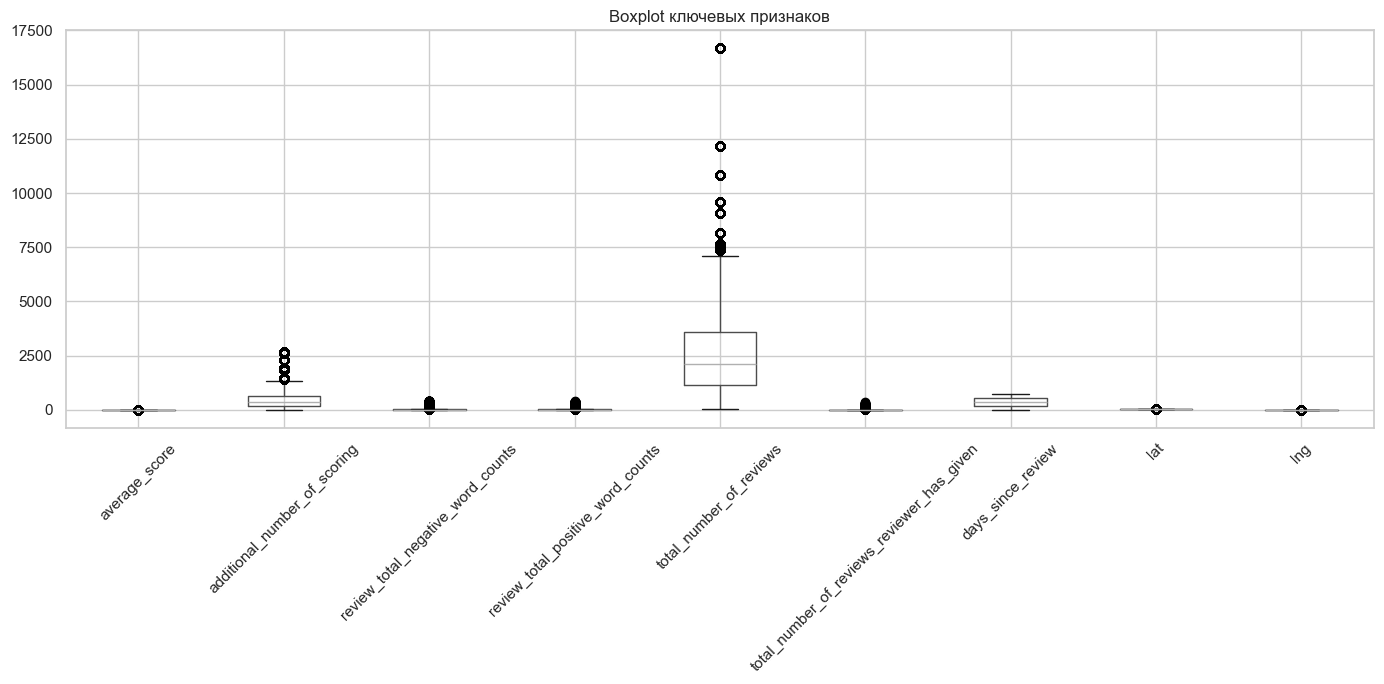

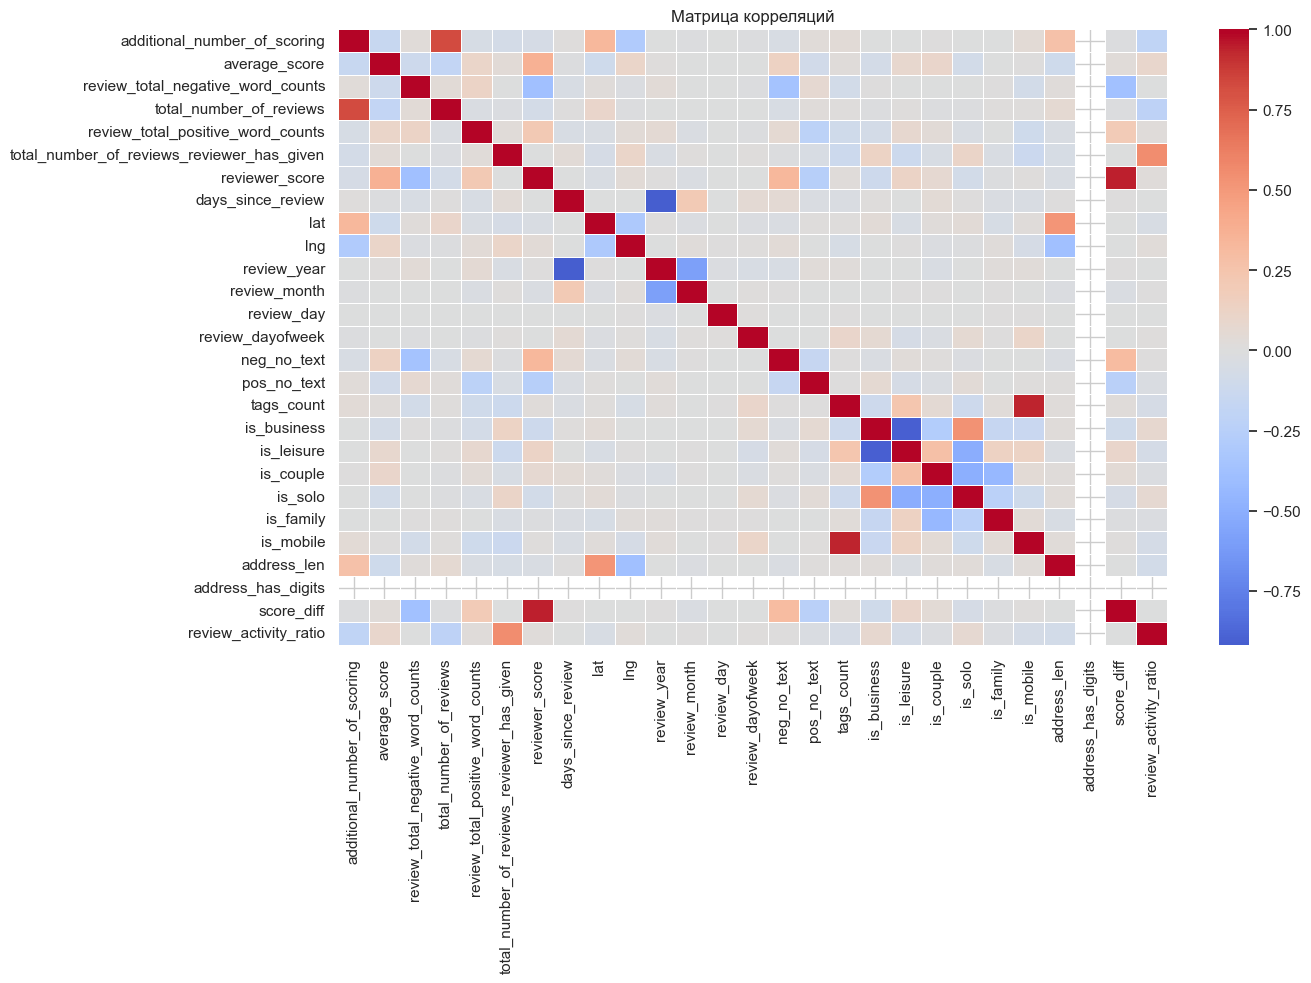

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
# Распределение reviewer_score
plt.figure(figsize=(10, 5))
sns.histplot(df_ml_final['reviewer_score'], bins=30, kde=True, color='steelblue')
plt.title('Распределение reviewer_score')
plt.xlabel('reviewer_score')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

# Boxplot по ключевым признакам
key_cols = [
    'average_score',
    'additional_number_of_scoring',
    'review_total_negative_word_counts',
    'review_total_positive_word_counts',
    'total_number_of_reviews',
    'total_number_of_reviews_reviewer_has_given',
    'days_since_review',
    'lat',
    'lng'
]

existing_cols = [col for col in key_cols if col in df_ml_final.columns]

plt.figure(figsize=(14, 7))
df_ml_final[existing_cols].boxplot(rot=45)
plt.title('Boxplot ключевых признаков')
plt.tight_layout()
plt.show()
# Heatmap корреляций
plt.figure(figsize=(14, 10))
corr = df_ml_final.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

In [57]:
table_score = df_ml_final['reviewer_score'].describe().to_frame().T
table_score

,count,mean,std,min,25%,50%,75%,max
reviewer_score,386803.0,8.396906,1.63609,2.5,7.5,8.8,9.6,10.0


In [58]:
key_cols = [
    'average_score',
    'additional_number_of_scoring',
    'review_total_negative_word_counts',
    'review_total_positive_word_counts',
    'total_number_of_reviews',
    'total_number_of_reviews_reviewer_has_given',
    'days_since_review',
    'lat',
    'lng'
]

existing_cols = [col for col in key_cols if col in df_ml_final.columns]

table_box = df_ml_final[existing_cols].describe().T
table_box

,count,mean,std,min,25%,50%,75%,max
average_score,386803.0,8.397231,0.547881,5.200000,8.100000,8.400000,8.800000,9.800000
additional_number_of_scoring,386803.0,498.246536,500.258012,1.000000,169.000000,342.000000,660.000000,2682.000000
review_total_negative_word_counts,386803.0,18.538988,29.703369,0.000000,2.000000,9.000000,23.000000,408.000000
review_total_positive_word_counts,386803.0,17.776985,21.726141,0.000000,5.000000,11.000000,22.000000,395.000000
total_number_of_reviews,386803.0,2743.992042,2316.457018,43.000000,1161.000000,2134.000000,3613.000000,16670.000000
total_number_of_reviews_reviewer_has_given,386803.0,7.177250,11.054420,1.000000,1.000000,3.000000,8.000000,355.000000
days_since_review,386803.0,354.387978,208.975174,0.000000,175.000000,353.000000,527.000000,730.000000
lat,386803.0,49.456537,3.459794,41.328376,48.214662,51.499981,51.516288,52.400181
lng,386803.0,2.805532,4.570019,-0.369758,-0.143372,-0.000250,4.831098,16.429233


In [59]:
corr = df_ml_final.corr(numeric_only=True).abs()

pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

pairs.columns = ['feature_1', 'feature_2', 'corr']
pairs = pairs.sort_values('corr', ascending=False)

pairs.head(20)

,feature_1,feature_2,corr
152,reviewer_score,score_diff,0.942321
285,tags_count,is_mobile,0.938654
156,days_since_review,review_year,0.917355
289,is_business,is_leisure,0.904145
2,additional_number_of_scoring,total_number_of_reviews,0.824467
205,review_year,review_month,0.581470
134,total_number_of_reviews_reviewer_has_given,review_activity_ratio,0.550676
291,is_business,is_solo,0.528590
186,lat,address_len,0.518706
298,is_leisure,is_solo,0.509337


# Обучение модели 

In [60]:
X = df_ml_final.drop(['reviewer_score'], axis = 1)  
y = df_ml_final['reviewer_score']  
       
from sklearn.model_selection import train_test_split  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели  
      
# Создаём модель  
regr = RandomForestRegressor(n_estimators=100)  
      
# Обучаем модель на тестовом наборе данных  
regr.fit(X_train, y_train)  

y_pred = regr.predict(X_test)

In [37]:
# модель
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.0001237439982364377
